# Desafío: Preparación de datos y gráficos
## Daniel Rojas López

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset de salarios
df = pd.read_csv("world-data-2023.csv",delimiter=',')
df.shape

(195, 35)

In [2]:
df.head(5)

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
0,Afghanistan,60,AF,58.10%,"652,230","323,000",32.49,93.0,Kabul,"8,672",...,78.40%,0.28,"38,041,754",48.90%,9.30%,71.40%,11.12%,"9,797,273",33.939110,67.709953
1,Albania,105,AL,43.10%,"28,748","9,000",11.78,355.0,Tirana,"4,536",...,56.90%,1.20,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593",41.153332,20.168331
2,Algeria,18,DZ,17.40%,"2,381,741","317,000",24.28,213.0,Algiers,"150,006",...,28.10%,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100",28.033886,1.659626
3,Andorra,164,AD,40.00%,468,NaN,7.20,376.0,Andorra la Vella,469,...,36.40%,3.33,"77,142",NaN,NaN,NaN,NaN,"67,873",42.506285,1.521801
4,Angola,26,AO,47.50%,"1,246,700","117,000",40.73,244.0,Luanda,"34,693",...,33.40%,0.21,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025",-11.202692,17.873887


In [3]:
df.columns

Index(['Country', 'Density\n(P/Km2)', 'Abbreviation', 'Agricultural Land( %)',
       'Land Area(Km2)', 'Armed Forces size', 'Birth Rate', 'Calling Code',
       'Capital/Major City', 'Co2-Emissions', 'CPI', 'CPI Change (%)',
       'Currency-Code', 'Fertility Rate', 'Forested Area (%)',
       'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Infant mortality',
       'Largest city', 'Life expectancy', 'Maternal mortality ratio',
       'Minimum wage', 'Official language', 'Out of pocket health expenditure',
       'Physicians per thousand', 'Population',
       'Population: Labor force participation (%)', 'Tax revenue (%)',
       'Total tax rate', 'Unemployment rate', 'Urban_population', 'Latitude',
       'Longitude'],
      dtype='object')

### 1. Carga los datos y genera un dataFrame que excluya las columnas correspondientesa la abreviatura del país, código de llamada, capital, código de moneda, ciudad más grande, lenguaje oficial, latitud y longitud. Considerando estos datos, realiza una inspección inicial sobre ellos, considerando gráficos. Concluye.


In [4]:
#1. Carga los datos y genera un dataFrame que excluya las columnas correspondientes a la 
# abreviatura del país,
# código de llamada,
# capital, 
# código de moneda,
# ciudad más grande, 
# lenguaje oficial, 
# latitud y longitud. 

# Considerando estos datos, realiza una inspección inicial sobre ellos, considerando gráficos. Concluye.

# Excluir las columnas especificadas
columns_to_exclude = [
    'Abbreviation',
    'Calling Code',
    'Capital/Major City',
    'Currency Code',
    'Official language',
    'Latitude',
    'Longitude'
]

# Filtrar las columnas que no están en la lista de exclusiones
df_filtrada = df.drop(columns=[col for col in columns_to_exclude if col in df.columns])
df_filtrada.head(10)


,Country,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Co2-Emissions,CPI,CPI Change (%),Currency-Code,...,Maternal mortality ratio,Minimum wage,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population
0,Afghanistan,60,58.10%,"652,230","323,000",32.49,"8,672",149.9,2.30%,AFN,...,638.0,$0.43,78.40%,0.28,"38,041,754",48.90%,9.30%,71.40%,11.12%,"9,797,273"
1,Albania,105,43.10%,"28,748","9,000",11.78,"4,536",119.05,1.40%,ALL,...,15.0,$1.12,56.90%,1.20,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593"
2,Algeria,18,17.40%,"2,381,741","317,000",24.28,"150,006",151.36,2.00%,DZD,...,112.0,$0.95,28.10%,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100"
3,Andorra,164,40.00%,468,NaN,7.20,469,NaN,NaN,EUR,...,NaN,$6.63,36.40%,3.33,"77,142",NaN,NaN,NaN,NaN,"67,873"
4,Angola,26,47.50%,"1,246,700","117,000",40.73,"34,693",261.73,17.10%,AOA,...,241.0,$0.71,33.40%,0.21,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025"
5,Antigua and Barbuda,223,20.50%,443,0,15.33,557,113.81,1.20%,XCD,...,42.0,$3.04,24.30%,2.76,"97,118",NaN,16.50%,43.00%,NaN,"23,800"
6,Argentina,17,54.30%,"2,780,400","105,000",17.02,"201,348",232.75,53.50%,ARS,...,39.0,$3.35,17.60%,3.96,"44,938,712",61.30%,10.10%,106.30%,9.79%,"41,339,571"
7,Armenia,104,58.90%,"29,743","49,000",13.99,"5,156",129.18,1.40%,AMD,...,26.0,$0.66,81.60%,4.40,"2,957,731",55.60%,20.90%,22.60%,16.99%,"1,869,848"
8,Australia,3,48.20%,"7,741,220","58,000",12.60,"375,908",119.8,1.60%,AUD,...,6.0,$13.59,19.60%,3.68,"25,766,605",65.50%,23.00%,47.40%,5.27%,"21,844,756"
9,Austria,109,32.40%,"83,871","21,000",9.70,"61,448",118.06,1.50%,EUR,...,5.0,NaN,17.90%,5.17,"8,877,067",60.70%,25.40%,51.40%,4.67%,"5,194,416"


In [5]:
df_filtrada.describe()


,Birth Rate,Fertility Rate,Infant mortality,Life expectancy,Maternal mortality ratio,Physicians per thousand
count,189.000000,188.000000,189.000000,187.000000,181.000000,188.000000
mean,20.214974,2.698138,21.332804,72.279679,160.392265,1.839840
std,9.945774,1.282267,19.548058,7.483661,233.502024,1.684261
min,5.900000,0.980000,1.400000,52.800000,2.000000,0.010000
25%,11.300000,1.705000,6.000000,67.000000,13.000000,0.332500
50%,17.950000,2.245000,14.000000,73.200000,53.000000,1.460000
75%,28.750000,3.597500,32.700000,77.500000,186.000000,2.935000
max,46.080000,6.910000,84.500000,85.400000,1150.000000,8.420000


In [6]:
#df_filtrada.describe()
#df_filtrada['Population'].describe()
df_filtrada['Life expectancy'].describe()


count    187.000000
mean      72.279679
std        7.483661
min       52.800000
25%       67.000000
50%       73.200000
75%       77.500000
max       85.400000
Name: Life expectancy, dtype: float64

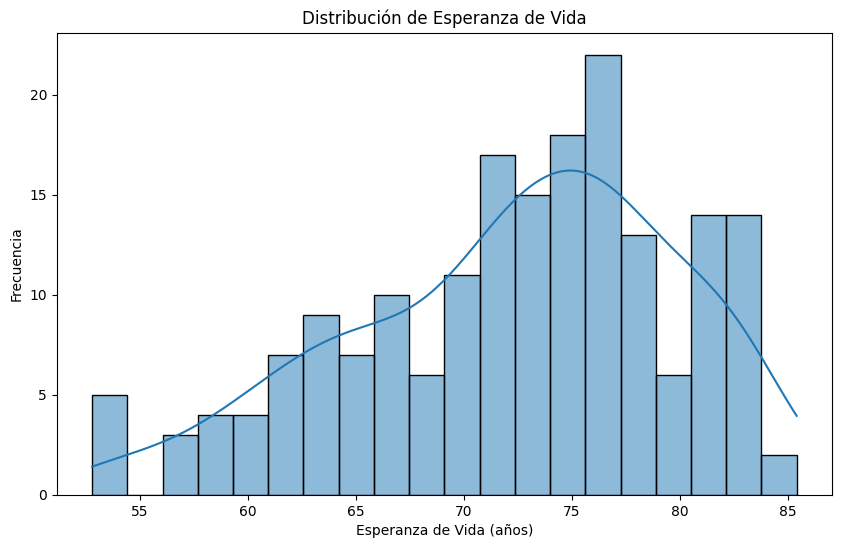

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df_filtrada['Life expectancy'], bins=20, kde=True)
plt.title('Distribución de Esperanza de Vida')
plt.xlabel('Esperanza de Vida (años)')
plt.ylabel('Frecuencia')
plt.show()

Como se observa en el gráfico histograma se puede decir que
la mayoría de los pacientes tienen una edad entre 67 y 77.5 años.
}
- Rango típico: 67-77.5 años (25%-75%)
- Promedio: 72.28 años
- Valores extremos: <60 años o >80 años


### 2. De las variables codificadas numéricamente, ¿hay pares de ellas en la que parezca haber correlación? ¿Para cuál(es) de ellas se observa más claramente?

In [8]:
#2. De las variables codificadas numéricamente, ¿hay pares de ellas en la que parezca haber correlación? ¿Para cuál(es) de ellas se observa más claramente?
#como graficar con un heatmap todas las variables

In [9]:
# Seleccionar solo columnas numéricas
numeric_columns = df_filtrada.select_dtypes(include=[np.number]).columns.tolist()

# Limpiar y convertir datos numéricos
df_numeric = df_filtrada[numeric_columns].copy()

# Convertir columnas con símbolos y formato
for col in df_numeric.columns:
    if df_numeric[col].dtype == 'object':
        # Remover símbolos de porcentaje, comas y otros caracteres
        df_numeric[col] = df_numeric[col].astype(str).str.replace('%', '').str.replace(',', '').str.replace('$', '').str.replace(' ', '')
        # Convertir a numérico
        df_numeric[col] = pd.to_numeric(df_numeric[col], errors='coerce')

# Calcular matriz de correlación
correlation_matrix = df_numeric.corr()

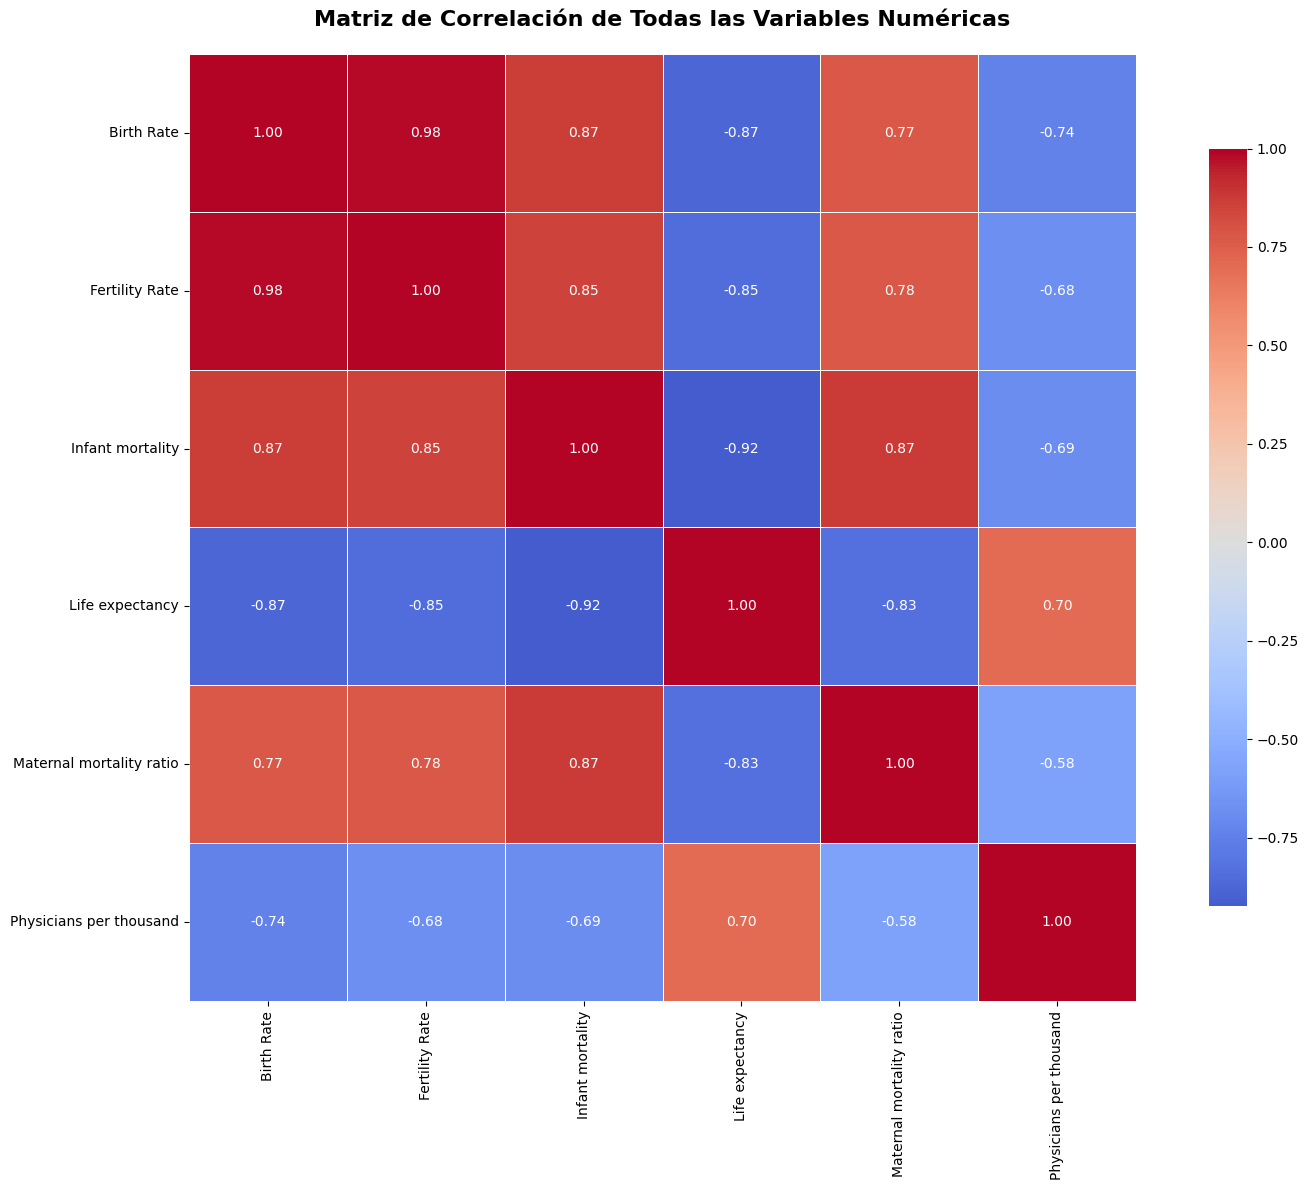

In [10]:
# Crear el heatmap
plt.figure(figsize=(16, 12))

# Configurar el heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,           # Mostrar valores de correlación
    cmap='coolwarm',      # Esquema de colores (rojo=positivo, azul=negativo)
    center=0,             # Centrar el colormap en 0
    square=True,          # Hacer las celdas cuadradas
    linewidths=0.5,       # Líneas entre celdas
    cbar_kws={"shrink": 0.8},  # Configurar barra de color
    fmt='.2f'            # Formato de números (2 decimales)
)

plt.title('Matriz de Correlación de Todas las Variables Numéricas', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

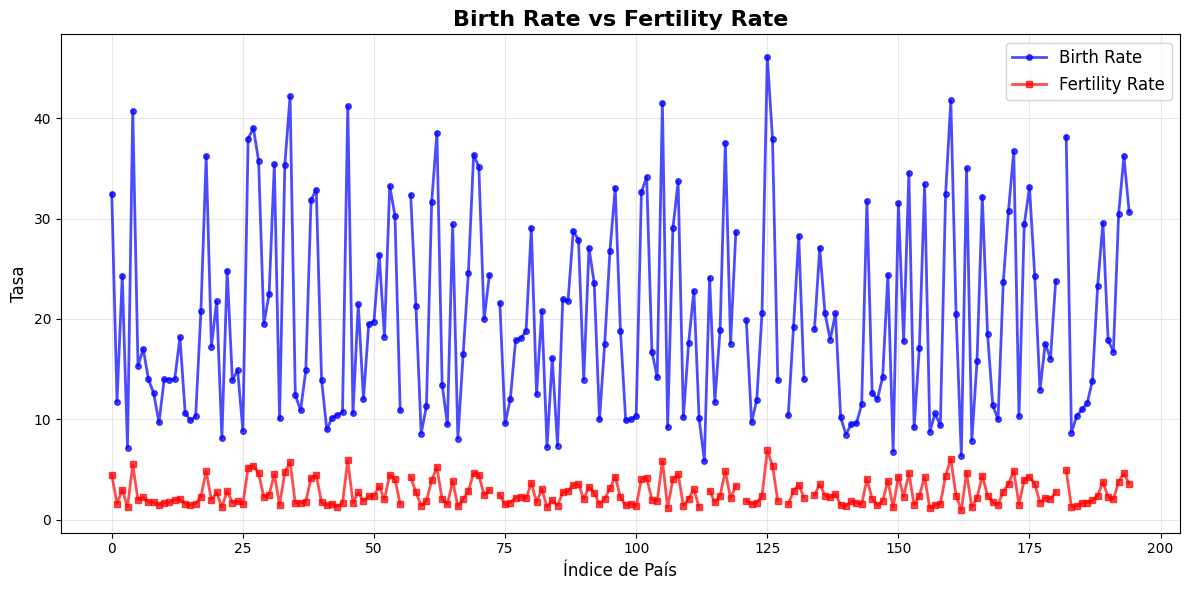

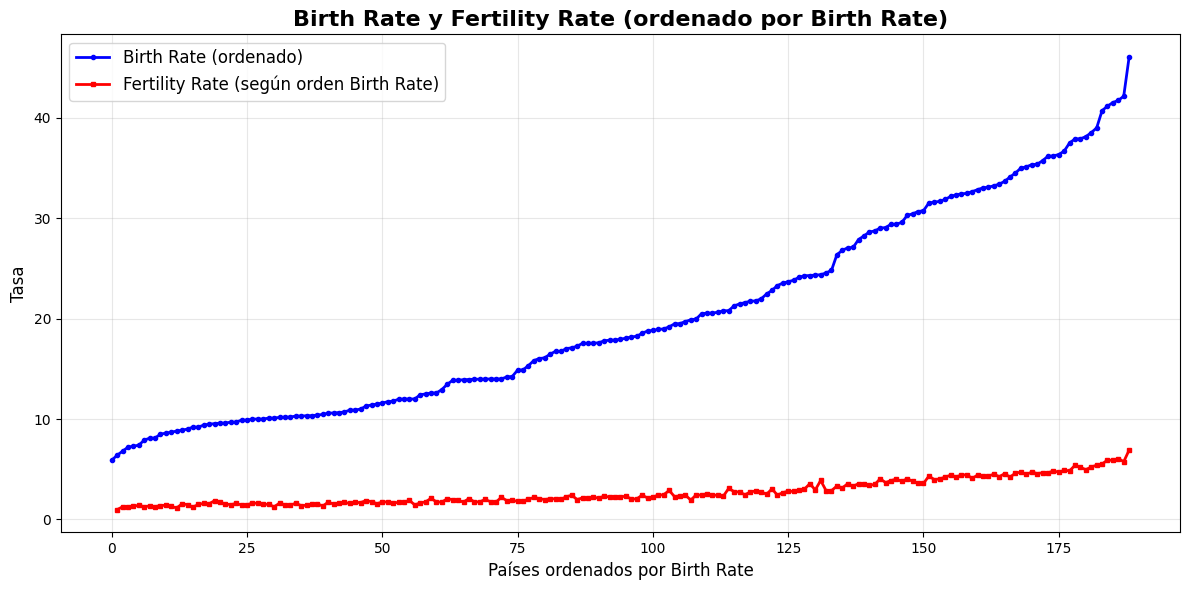

Estadísticas de las variables:
Birth Rate - Media: 20.21, Desv. Std: 9.95
Fertility Rate - Media: 2.70, Desv. Std: 1.28
Correlación: 0.9811


In [11]:
# Crear gráfico lineal para Birth Rate y Fertility Rate
plt.figure(figsize=(12, 6))

# Ordenar los datos por índice para mejor visualización
df_line = df_numeric[['Birth Rate', 'Fertility Rate']].copy()
df_line = df_line.sort_index()

# Graficar ambas variables
plt.plot(df_line.index, df_line['Birth Rate'], 
         label='Birth Rate', 
         color='blue', 
         linewidth=2, 
         marker='o', 
         markersize=4, 
         alpha=0.7)

plt.plot(df_line.index, df_line['Fertility Rate'], 
         label='Fertility Rate', 
         color='red', 
         linewidth=2, 
         marker='s', 
         markersize=4, 
         alpha=0.7)

# Configurar el gráfico
plt.title('Birth Rate vs Fertility Rate', fontsize=16, fontweight='bold')
plt.xlabel('Índice de País', fontsize=12)
plt.ylabel('Tasa', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Alternativa: Gráfico con ordenamiento por una de las variables
plt.figure(figsize=(12, 6))

# Ordenar por Birth Rate para ver la tendencia
df_sorted = df_numeric[['Birth Rate', 'Fertility Rate']].copy()
df_sorted = df_sorted.sort_values('Birth Rate')

plt.plot(range(len(df_sorted)), df_sorted['Birth Rate'], 
         label='Birth Rate (ordenado)', 
         color='blue', 
         linewidth=2, 
         marker='o', 
         markersize=3)

plt.plot(range(len(df_sorted)), df_sorted['Fertility Rate'], 
         label='Fertility Rate (según orden Birth Rate)', 
         color='red', 
         linewidth=2, 
         marker='s', 
         markersize=3)

plt.title('Birth Rate y Fertility Rate (ordenado por Birth Rate)', fontsize=16, fontweight='bold')
plt.xlabel('Países ordenados por Birth Rate', fontsize=12)
plt.ylabel('Tasa', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar estadísticas básicas
print("Estadísticas de las variables:")
print(f"Birth Rate - Media: {df_numeric['Birth Rate'].mean():.2f}, Desv. Std: {df_numeric['Birth Rate'].std():.2f}")
print(f"Fertility Rate - Media: {df_numeric['Fertility Rate'].mean():.2f}, Desv. Std: {df_numeric['Fertility Rate'].std():.2f}")
print(f"Correlación: {df_numeric['Birth Rate'].corr(df_numeric['Fertility Rate']):.4f}")

La fuerte correlación positiva entre Birth Rate y Fertility Rate confirma que ambas son indicadores robustos del crecimiento demográfico. Esta relación permite usar cualquiera de las dos variables como proxy para analizar tendencias poblacionales, planificar recursos y diseñar políticas demográficas efectivas

### 3. Considera los dos pares de variables anteriores y elimina en cada caso los faltantes y atípicos. Justifica en cada caso tu procedimiento.

In [ ]:
# Seleccionar solo las columnas Birth Rate y Fertility Rate y eliminar los caso faltantes y atipicos
df_seleccionado = df[['Birth Rate', 'Fertility Rate']]

df_seleccionado.info()

df_seleccionado.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Birth Rate      189 non-null    float64
 1   Fertility Rate  188 non-null    float64
dtypes: float64(2)
memory usage: 3.2 KB


,Birth Rate,Fertility Rate
0,32.49,4.47
1,11.78,1.62
2,24.28,3.02
3,7.20,1.27
4,40.73,5.52


In [14]:
# Verificación rápida de nulos en todo el DataFrame
print("¿Hay algún nulo en el DataFrame?", df_seleccionado.isnull().any().any())
 
# Columnas con nulos
columnas_con_nulos = df_seleccionado.columns[df_seleccionado.isnull().any()].tolist()
print("Columnas con nulos:", columnas_con_nulos)
 
# Estadísticas de nulos
print("\nEstadísticas de nulos:")
print(df_seleccionado.isnull().describe())

¿Hay algún nulo en el DataFrame? True
Columnas con nulos: ['Birth Rate', 'Fertility Rate']

Estadísticas de nulos:
       Birth Rate Fertility Rate
count         195            195
unique          2              2
top         False          False
freq          189            188


In [17]:
# Seleccionar solo las columnas Birth Rate y Fertility Rate
df_birth_fertility = df_numeric[['Birth Rate', 'Fertility Rate']].copy()

print("=== DATOS ORIGINALES ===")
print(f"Forma original: {df_birth_fertility.shape}")
print(f"Datos nulos:\n{df_birth_fertility.isnull().sum()}")
print(f"Estadísticas originales:\n{df_birth_fertility.describe()}")

# 1. Eliminar casos faltantes (valores nulos)
df_sin_nulos = df_birth_fertility.dropna()

print(f"\n=== DESPUÉS DE ELIMINAR NULOS ===")
print(f"Forma sin nulos: {df_sin_nulos.shape}")
print(f"Se eliminaron {len(df_birth_fertility) - len(df_sin_nulos)} filas con nulos")

# 2. Eliminar casos atípicos usando método IQR
def eliminar_atipicos_iqr(df, columna):
    """
    Elimina atípicos usando el método del rango intercuartílico (IQR)
    """
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    
    # Límites para identificar atípicos
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    print(f"\nAnálisis de atípicos para {columna}:")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Límite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    
    # Identificar atípicos
    atipicos_inferiores = (df[columna] < limite_inferior).sum()
    atipicos_superiores = (df[columna] > limite_superior).sum()
    total_atipicos = atipicos_inferiores + atipicos_superiores
    
    print(f"Atípicos inferiores: {atipicos_inferiores}")
    print(f"Atípicos superiores: {atipicos_superiores}")
    print(f"Total atípicos: {total_atipicos}")
    
    # Filtrar datos sin atípicos
    df_sin_atipicos = df[(df[columna] >= limite_inferior) & 
                         (df[columna] <= limite_superior)]
    
    return df_sin_atipicos, total_atipicos

# Eliminar atípicos para Birth Rate
df_limpio_br, atipicos_br = eliminar_atipicos_iqr(df_sin_nulos, 'Birth Rate')

# Eliminar atípicos para Fertility Rate
df_final, atipicos_fr = eliminar_atipicos_iqr(df_limpio_br, 'Fertility Rate')

=== DATOS ORIGINALES ===
Forma original: (195, 2)
Datos nulos:
Birth Rate        6
Fertility Rate    7
dtype: int64
Estadísticas originales:
       Birth Rate  Fertility Rate
count  189.000000      188.000000
mean    20.214974        2.698138
std      9.945774        1.282267
min      5.900000        0.980000
25%     11.300000        1.705000
50%     17.950000        2.245000
75%     28.750000        3.597500
max     46.080000        6.910000

=== DESPUÉS DE ELIMINAR NULOS ===
Forma sin nulos: (188, 2)
Se eliminaron 7 filas con nulos

Análisis de atípicos para Birth Rate:
Q1: 11.38
Q3: 28.82
IQR: 17.45
Límite inferior: -14.79
Límite superior: 54.99
Atípicos inferiores: 0
Atípicos superiores: 0
Total atípicos: 0

Análisis de atípicos para Fertility Rate:
Q1: 1.71
Q3: 3.60
IQR: 1.89
Límite inferior: -1.13
Límite superior: 6.44
Atípicos inferiores: 0
Atípicos superiores: 1
Total atípicos: 1


### 4. Construye un gráfico para verificar la correlación entre estas variables, ahora con los datos preparados. Compara con lo obtenido anteriormente.


=== DATOS FINALES LIMPIOS ===
Forma final: (187, 2)
Total atípicos eliminados: 1
Total datos eliminados: 8
Porcentaje de datos conservados: 95.9%

Estadísticas finales:
       Birth Rate  Fertility Rate
count  187.000000      187.000000
mean    20.153209        2.675615
std      9.761134        1.247864
min      6.400000        0.980000
25%     11.350000        1.700000
50%     17.950000        2.240000
75%     28.695000        3.580000
max     42.170000        6.070000


C:\Users\drolo\AppData\Local\Temp\ipykernel_14984\2370747380.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([df_final['Birth Rate'], df_final['Fertility Rate']],


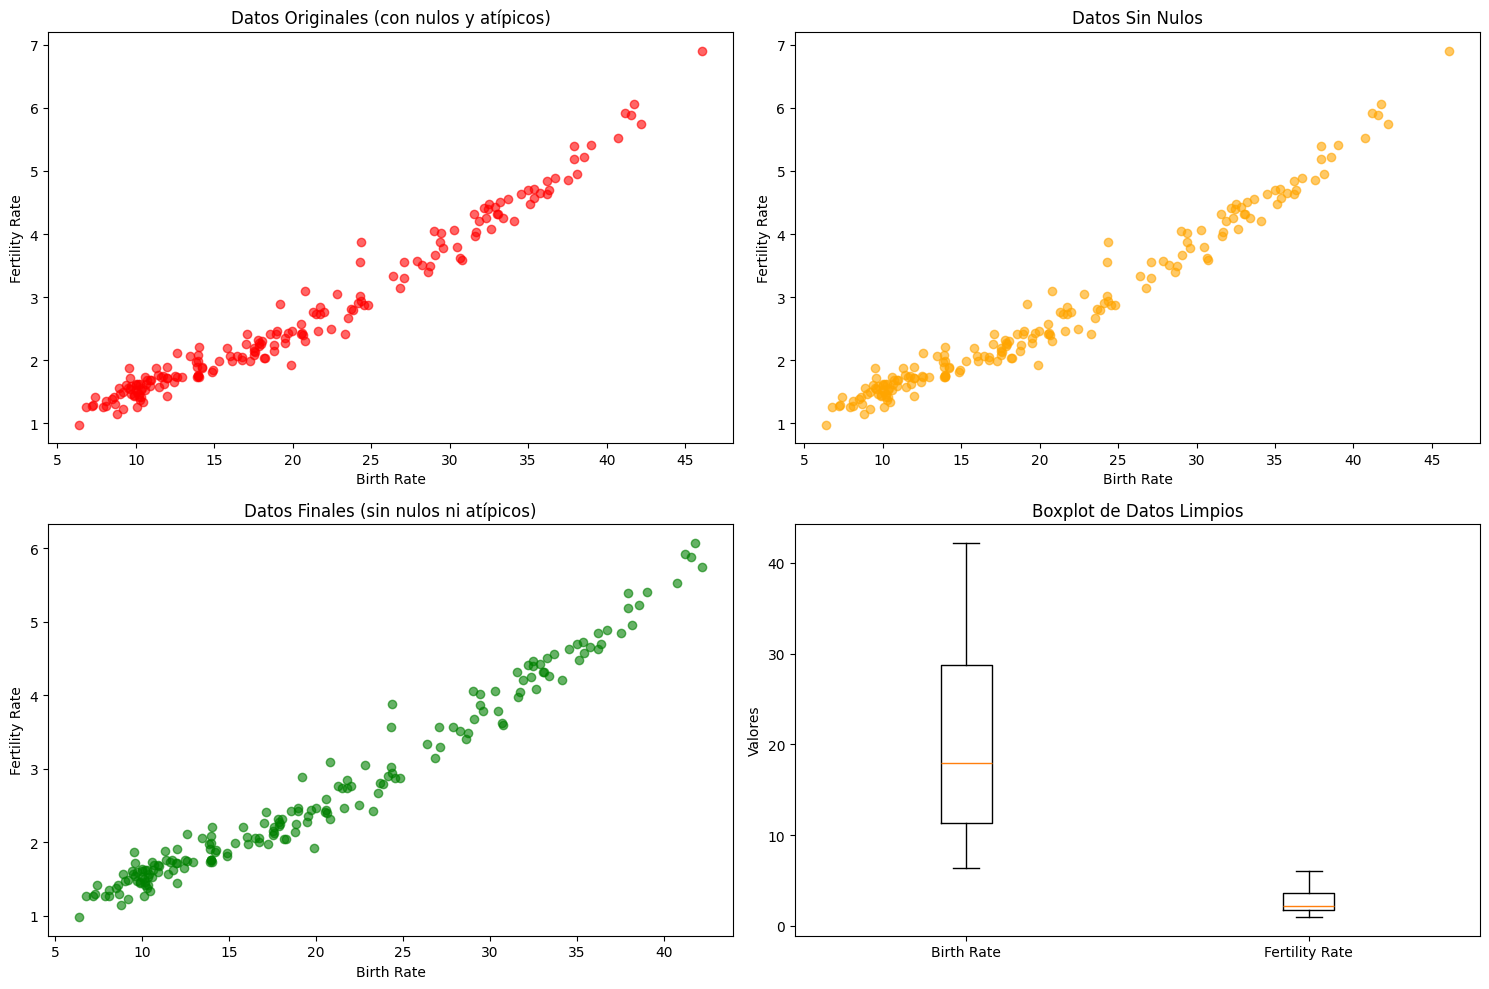


=== COMPARACIÓN DE CORRELACIONES ===
Correlación original: 0.9811
Correlación final: 0.9815
Cambio en correlación: +0.0004


In [ ]:
print(f"\n=== DATOS FINALES LIMPIOS ===")
print(f"Forma final: {df_final.shape}")
print(f"Total atípicos eliminados: {atipicos_br + atipicos_fr}")
print(f"Total datos eliminados: {len(df_birth_fertility) - len(df_final)}")
print(f"Porcentaje de datos conservados: {(len(df_final)/len(df_birth_fertility)*100):.1f}%")

print(f"\nEstadísticas finales:")
print(df_final.describe())

# Visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Datos originales
axes[0, 0].scatter(df_birth_fertility['Birth Rate'], df_birth_fertility['Fertility Rate'], 
                   alpha=0.6, color='red')
axes[0, 0].set_title('Datos Originales (con nulos y atípicos)')
axes[0, 0].set_xlabel('Birth Rate')
axes[0, 0].set_ylabel('Fertility Rate')

# Datos sin nulos
axes[0, 1].scatter(df_sin_nulos['Birth Rate'], df_sin_nulos['Fertility Rate'], 
                   alpha=0.6, color='orange')
axes[0, 1].set_title('Datos Sin Nulos')
axes[0, 1].set_xlabel('Birth Rate')
axes[0, 1].set_ylabel('Fertility Rate')

# Datos finales limpios
axes[1, 0].scatter(df_final['Birth Rate'], df_final['Fertility Rate'], 
                   alpha=0.6, color='green')
axes[1, 0].set_title('Datos Finales (sin nulos ni atípicos)')
axes[1, 0].set_xlabel('Birth Rate')
axes[1, 0].set_ylabel('Fertility Rate')

# Boxplots para visualizar atípicos
axes[1, 1].boxplot([df_final['Birth Rate'], df_final['Fertility Rate']], 
                    labels=['Birth Rate', 'Fertility Rate'])
axes[1, 1].set_title('Boxplot de Datos Limpios')
axes[1, 1].set_ylabel('Valores')

plt.tight_layout()
plt.show()

# Calcular correlaciones antes y después
print("\n=== COMPARACIÓN DE CORRELACIONES ===")
correlacion_original = df_birth_fertility['Birth Rate'].corr(df_birth_fertility['Fertility Rate'])
correlacion_final = df_final['Birth Rate'].corr(df_final['Fertility Rate'])

print(f"Correlación original: {correlacion_original:.4f}")
print(f"Correlación final: {correlacion_final:.4f}")
print(f"Cambio en correlación: {correlacion_final - correlacion_original:+.4f}")

Despues de realizar la limpieza de datos, se puede observar que mejoro la correlación entre las variables. de 0.981 a 0.9815

### 5. Realiza lo mismo para comparar la cantidad de médicos por cada mil personas y la esperanza de vida. ¿Qué puedes concluir?

### 6. Construye un gráfico para representar la población total de los países y su producto interno bruto. Prepara los datos y escoge el gráfico adecuado (si es necesario, limpiay/o transforma los datos). Justifica

### 7. Escoge otro par de datos, límpialos, prepáralos y analiza su posible relación. Justifica utilizando las herramientas vistas y gráficos adecuados
